# Phân tích Khám phá Dữ liệu (EDA) - Chi phí FinOps & Metric Tài nguyên
**Dự án:** FinOps Watch (Báo cáo thực hành TF2 Capstone)
**Tác giả:** Antigravity AI & Pair Programmer
**Ngày thực hiện:** Tháng 6, 2026

### Mục tiêu nghiên cứu:
1. **Thiết lập Từ điển dữ liệu (Data Dictionary)** để phục vụ quá trình huấn luyện mô hình (Modeling).
2. **Phân tích chất lượng dữ liệu & KPI**: Khảo sát giá trị thiếu, trùng lặp và đánh giá chất lượng dữ liệu đầu vào qua các chỉ số KPI định lượng.
3. **Phân tích dữ liệu chi phí AWS FinOps (`tf2-finops`)**: Khảo sát chi phí tổng quan theo ngày, phân phối chi phí theo tài khoản liên kết (linked account), theo dịch vụ (service), và lượng chi tiêu không gắn tag (untagged spend).
4. **Phân tích dữ liệu metric hiệu năng tài nguyên (`metrics_haikhoa`)**: Khảo sát các thông số hiệu năng (CPU, Memory, Network, Disk I/O, số lượng kết nối DB, sử dụng GPU) của các dịch vụ chính.
5. **Phân tích phân phối giữa các lớp (Class Distributions & Separability)**: Đánh giá thống kê đặc trưng và mức độ phân tách của các thuộc tính hiệu năng giữa các lớp `normal`, `anomaly`, và `benign`.
6. **Phân tích tương quan & ngoại lai (Correlation & Outliers)**: Khảo sát ma trận tương quan đầy đủ giữa các biến số, in ra các hệ số tương quan cụ thể và thống kê tỷ lệ ngoại lai.
7. **Phân tích trôi dạt dữ liệu theo thời gian (Data Drift)**: Kiểm tra phân phối dữ liệu hiệu năng và chi phí có bị trôi dạt từ tháng đầu tiên sang tháng cuối cùng của kỳ backtest hay không.
8. **Phân tích sâu các Anomalies mẫu đã dán nhãn**: Khảo sát các mẫu dán nhãn công khai (A2 - RDS nhàn rỗi, A6 - CloudWatch spike, B2 - Migration dữ liệu hợp lệ).
9. **Tổng kết KPI cuối Notebook**: Cung cấp bảng đánh giá chất lượng tổng hợp phục vụ pha Modeling tiếp theo.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import json
import warnings
from scipy.stats import ks_2samp
warnings.filterwarnings('ignore')

# Thiết lập giao diện biểu đồ
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

# Tự động phát hiện thư mục chứa dữ liệu tùy thuộc vào vị trí thực thi notebook
if os.path.exists(r"data/tf2-finops"):
    DATA_TF_DIR = r"data/tf2-finops"
    DATA_HK_DIR = r"data/metrics_haikhoa"
elif os.path.exists(r"../tf2-finops"):
    DATA_TF_DIR = r"../tf2-finops"
    DATA_HK_DIR = r"../metrics_haikhoa"
else:
    DATA_TF_DIR = r"C:\Users\ASUS\OneDrive\Obsidian Vault\XBrain-Phase2\Capstone_Project\data\tf2-finops"
    DATA_HK_DIR = r"C:\Users\ASUS\OneDrive\Obsidian Vault\XBrain-Phase2\Capstone_Project\data\metrics_haikhoa"

print(f"Đường dẫn dữ liệu đã được cấu hình:\n - TF2 FinOps: {DATA_TF_DIR}\n - Metrics: {DATA_HK_DIR}")

Đường dẫn dữ liệu đã được cấu hình:
 - TF2 FinOps: ../tf2-finops
 - Metrics: ../metrics_haikhoa


## 1. Từ điển Dữ liệu (Data Dictionary)
Phần này định nghĩa ý nghĩa và đơn vị của các trường dữ liệu chính, rất hữu ích cho quá trình phân tích đặc trưng và xây dựng mô hình phát hiện bất thường.

### 1.1 Dữ liệu Chi phí FinOps (`cur_line_items.csv` & `cost_explorer_daily.csv`)
| Cột (Feature) | Ý nghĩa (Meaning) | Đơn vị (Unit) | Mô tả thêm |
|---|---|---|---|
| `line_item_usage_start_date` / `date` | Ngày phát sinh chi phí | YYYY-MM-DD | Phân giải theo ngày |
| `line_item_usage_account_id` / `linked_account_id` | ID của tài khoản AWS thành viên | Số định danh | Tài khoản liên kết |
| `line_item_usage_account_name` / `linked_account_name` | Tên tài khoản AWS thành viên | Chuỗi ký tự | Ví dụ: `prod-core`, `staging`, `dev` |
| `line_item_product_code` / `service_code` | Mã định danh dịch vụ AWS | Chuỗi | Ví dụ: `AmazonEC2`, `AmazonRDS` |
| `service` | Tên dịch vụ hiển thị trên Cost Explorer | Chuỗi | Ví dụ: `Amazon Elastic Compute Cloud - Compute` |
| `line_item_resource_id` / `resource_id` | ID của tài nguyên cụ thể | Chuỗi | Dùng để phân bổ chi phí chi tiết |
| `line_item_unblended_cost` / `unblended_cost` | Chi phí thực tế chưa phân bổ | USD | Nguồn sự thật để phát hiện bất thường |
| `line_item_usage_amount` | Lượng tài nguyên tiêu dùng trong ngày | Số thực | Số giờ máy ảo chạy, dung lượng lưu trữ... |
| `pricing_unit` | Đơn vị tính giá tài nguyên | Chuỗi | Ví dụ: `Hrs`, `GB-Month` |
| `line_item_unblended_rate` | Đơn giá chưa phân bổ | USD | Đơn giá tại thời điểm tiêu dùng |
| `resource_tags_user_team` | Thẻ tag Đội nhóm quản lý | Chuỗi | Nếu trống là tài nguyên chưa phân bổ |
| `is_estimated` | Chi phí đang là ước tính | Boolean | `True` ở 2 ngày cuối cùng của chu kỳ |

### 1.2 Dữ liệu Metric Hiệu năng Tài nguyên (`metrics_haikhoa`)
| Cột (Feature) | Ý nghĩa (Meaning) | Đơn vị (Unit) | Mô tả thêm |
|---|---|---|---|
| `resource_id` | ID hoặc ARN của tài nguyên | Chuỗi | Dùng để join với dữ liệu CUR |
| `timestamp` | Ngày ghi nhận metric | YYYY-MM-DD | Khớp với ngày trong CUR |
| `cpu_percent` | Tỷ lệ sử dụng CPU trung bình trong ngày | % | Mức độ bận rộn CPU |
| `memory_mib` | Bộ nhớ RAM sử dụng trung bình trong ngày | MiB | Lượng RAM tiêu thụ |
| `network_in_bytes` | Lưu lượng mạng đi vào | Bytes | Network Inbound |
| `network_out_bytes` | Lưu lượng mạng đi ra | Bytes | Network Outbound |
| `disk_io_ops` | Số thao tác đọc/ghi đĩa trung bình | Ops | Disk I/O |
| `database_connections` | Số kết nối cơ sở dữ liệu đồng thời | Số kết nối | Chỉ có ở RDS (`rds_metrics.csv`) |
| `gpu_utilization` | Tỷ lệ sử dụng bộ xử lý đồ họa GPU | % | Chỉ có ở EC2 GPU & SageMaker |
| `cpu_h0` đến `cpu_h23` | Tỷ lệ sử dụng CPU trung bình theo từng giờ trong ngày | % | Đại diện cho profile hiệu năng theo giờ |
| `label` | Nhãn phân loại trạng thái hoạt động | Danh mục | `normal` (bình thường), `anomaly` (bất thường), `benign` (đột biến hợp lệ) |

## 2. Tải các Bộ dữ liệu
Tải dữ liệu chi phí và dữ liệu metric chi tiết của từng dịch vụ từ các thư mục dữ liệu đã cấu hình.

In [2]:
# Tải dữ liệu Cost Explorer, dòng chi phí CUR và nhãn mẫu
df_ce = pd.read_csv(os.path.join(DATA_TF_DIR, "cost_explorer_daily.csv"), parse_dates=["date"])
df_cur = pd.read_csv(os.path.join(DATA_TF_DIR, "cur_line_items.csv"), parse_dates=["line_item_usage_start_date"])
df_labels = pd.read_csv(os.path.join(DATA_TF_DIR, "anomaly_labels_public.csv"))

# Tải dữ liệu metric hiệu năng của từng nhóm dịch vụ
df_m_ec2 = pd.read_csv(os.path.join(DATA_HK_DIR, "ec2_metrics.csv"), parse_dates=["timestamp"])
df_m_rds = pd.read_csv(os.path.join(DATA_HK_DIR, "rds_metrics.csv"), parse_dates=["timestamp"])
df_m_ddb = pd.read_csv(os.path.join(DATA_HK_DIR, "ddb_metrics.csv"), parse_dates=["timestamp"])
df_m_sm = pd.read_csv(os.path.join(DATA_HK_DIR, "sagemaker_metrics.csv"), parse_dates=["timestamp"])
df_m_other = pd.read_csv(os.path.join(DATA_HK_DIR, "other_services_metrics.csv"), parse_dates=["timestamp"])

print(f"Tải xong Cost Explorer: {df_ce.shape[0]} dòng")
print(f"Tải xong CUR Line Items: {df_cur.shape[0]} dòng")
print(f"Tải xong các nhãn mẫu (Labels): {df_labels.shape[0]} dòng")
print(f"Metrics tải được - EC2: {df_m_ec2.shape[0]}, RDS: {df_m_rds.shape[0]}, DynamoDB: {df_m_ddb.shape[0]}, SageMaker: {df_m_sm.shape[0]}, Khác: {df_m_other.shape[0]}")

Tải xong Cost Explorer: 2770 dòng
Tải xong CUR Line Items: 24533 dòng
Tải xong các nhãn mẫu (Labels): 3 dòng
Metrics tải được - EC2: 10308, RDS: 1545, DynamoDB: 245, SageMaker: 1104, Khác: 11331


## 3. Báo cáo Chất lượng Dữ liệu Đầu vào & Đánh giá KPI
Đánh giá một cách định lượng chất lượng dữ liệu để phát hiện sớm các vấn đề về dữ liệu thiếu, trùng lặp và xác lập các chỉ số KPI đo lường chất lượng.

In [3]:
print("=== 3.1 BÁO CÁO GIÁ TRỊ THIẾU (MISSING VALUES) ===")
datasets = {
    "Cost Explorer": df_ce,
    "CUR Line Items": df_cur,
    "EC2 Metrics": df_m_ec2,
    "RDS Metrics": df_m_rds,
    "SageMaker Metrics": df_m_sm,
    "DynamoDB Metrics": df_m_ddb,
    "Other Metrics": df_m_other
}

for name, df in datasets.items():
    missing = df.isnull().sum()
    missing = missing[missing > 0]
    if len(missing) > 0:
        pct = (missing / len(df)) * 100
        report = pd.DataFrame({"Số dòng thiếu": missing, "Tỷ lệ (%)": pct})
        print(f"\nBộ dữ liệu: {name}")
        print(report.to_string())
    else:
        print(f"Bộ dữ liệu: {name} -> 0 dòng thiếu.")

print("\n=== 3.2 BÁO CÁO BẢN GHI TRÙNG LẶP (DUPLICATED ROWS) ===")
dup_list = []
for name, df in datasets.items():
    dups = df.duplicated().sum()
    pct = (dups / len(df)) * 100
    dup_list.append({"Bộ dữ liệu": name, "Số lượng trùng lặp": dups, "Tỷ lệ (%)": pct})
df_dups = pd.DataFrame(dup_list)
print(df_dups.to_string(index=False))

print("\n=== 3.3 KPI ĐỊNH LƯỢNG CHẤT LƯỢNG DỮ LIỆU ĐẦU VÀO ===")
kpis = []

# KPI 1: Completeness of critical columns (Độ hoàn thiện cột quan trọng)
cur_completeness = (1 - (df_cur[["line_item_resource_id", "line_item_unblended_cost", "line_item_usage_start_date"]].isnull().any(axis=1).sum() / len(df_cur))) * 100
kpis.append({"Chỉ số KPI": "Độ hoàn thiện CUR (Resource ID, Cost, Date)", "Giá trị đạt được (%)": cur_completeness, "Mục tiêu (%)": ">= 99.9%"})

ec2_completeness = (1 - (df_m_ec2[["resource_id", "timestamp", "cpu_percent", "label"]].isnull().any(axis=1).sum() / len(df_m_ec2))) * 100
kpis.append({"Chỉ số KPI": "Độ hoàn thiện EC2 Metrics (Resource ID, CPU, Label)", "Giá trị đạt được (%)": ec2_completeness, "Mục tiêu (%)": ">= 99.9%"})

# KPI 2: Uniqueness rate (Tỷ lệ duy nhất không trùng lặp)
cur_uniqueness = (1 - (df_cur.duplicated().sum() / len(df_cur))) * 100
kpis.append({"Chỉ số KPI": "Tính duy nhất của CUR (Không trùng lặp dòng)", "Giá trị đạt được (%)": cur_uniqueness, "Mục tiêu (%)": "100.0%"})

# KPI 3: Tagging Compliance rate (Tỷ lệ gắn Tag đội nhóm quản lý trong CUR)
cur_tag_rate = (df_cur["resource_tags_user_team"].notnull() & (df_cur["resource_tags_user_team"] != "")).sum() / len(df_cur) * 100
kpis.append({"Chỉ số KPI": "Tỷ lệ tuân thủ gắn Tag trong CUR (resource_tags_user_team)", "Giá trị đạt được (%)": cur_tag_rate, "Mục tiêu (%)": ">= 80.0%"})

# KPI 4: Validity rate (Mức độ hợp lệ của miền giá trị: Cost >= 0 và CPU trong [0,100])
valid_cost_pct = (df_cur["line_item_unblended_cost"] >= 0).sum() / len(df_cur) * 100
kpis.append({"Chỉ số KPI": "Tính hợp lệ của CUR Cost (Chi phí không âm)", "Giá trị đạt được (%)": valid_cost_pct, "Mục tiêu (%)": "100.0%"})

valid_cpu_pct = df_m_ec2["cpu_percent"].between(0, 100).sum() / len(df_m_ec2) * 100
kpis.append({"Chỉ số KPI": "Tính hợp lệ của EC2 CPU % (Thuộc khoảng [0, 100])", "Giá trị đạt được (%)": valid_cpu_pct, "Mục tiêu (%)": "100.0%"})

df_kpis = pd.DataFrame(kpis)
print(df_kpis.to_string(index=False))

=== 3.1 BÁO CÁO GIÁ TRỊ THIẾU (MISSING VALUES) ===
Bộ dữ liệu: Cost Explorer -> 0 dòng thiếu.

Bộ dữ liệu: CUR Line Items
                          Số dòng thiếu  Tỷ lệ (%)
product_instance_type             10472  42.685363
resource_tags_user_team              92   0.375005
resource_tags_user_owner          24443  99.633147

Bộ dữ liệu: EC2 Metrics
                 Số dòng thiếu  Tỷ lệ (%)
gpu_utilization          10218  99.126892
Bộ dữ liệu: RDS Metrics -> 0 dòng thiếu.
Bộ dữ liệu: SageMaker Metrics -> 0 dòng thiếu.
Bộ dữ liệu: DynamoDB Metrics -> 0 dòng thiếu.
Bộ dữ liệu: Other Metrics -> 0 dòng thiếu.

=== 3.2 BÁO CÁO BẢN GHI TRÙNG LẶP (DUPLICATED ROWS) ===
       Bộ dữ liệu  Số lượng trùng lặp  Tỷ lệ (%)
    Cost Explorer                   0        0.0
   CUR Line Items                   0        0.0
      EC2 Metrics                   0        0.0
      RDS Metrics                   0        0.0
SageMaker Metrics                   0        0.0
 DynamoDB Metrics                   0

## 4. Khám phá Dữ liệu Chi phí FinOps
Trong phần này, chúng ta sẽ khảo sát sự phân bổ và xu hướng chi tiêu theo thời gian, theo tài khoản liên kết, và theo từng dịch vụ.

### 4.1 Biểu đồ Chi phí theo Ngày
Vẽ biểu đồ đường tổng chi tiêu hàng ngày trên AWS để xem xu hướng tổng quát và phát hiện các điểm chi phí bất thường.

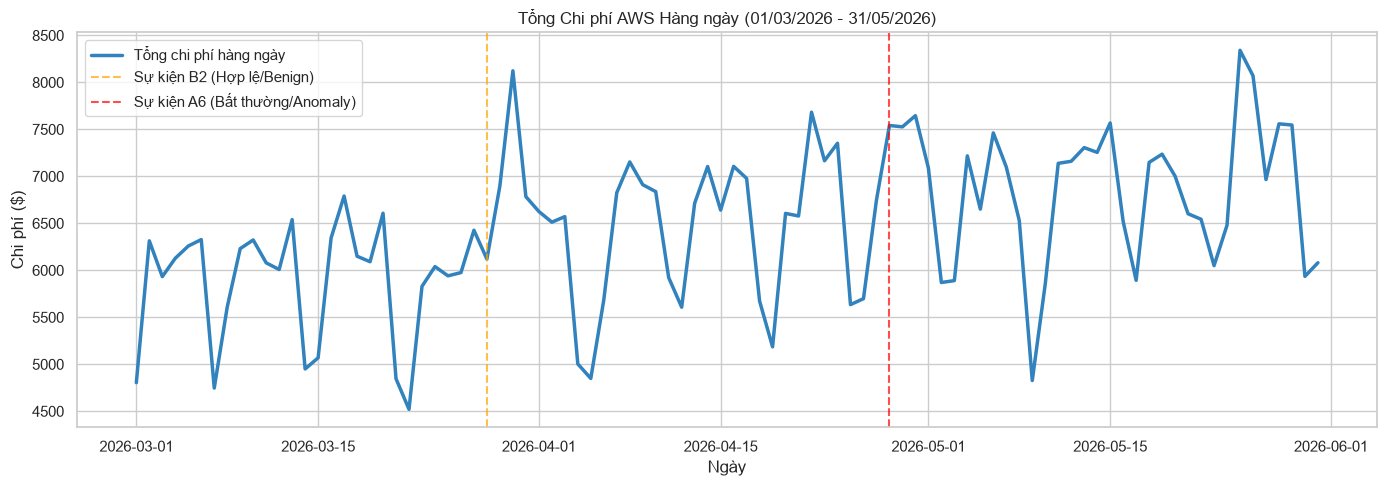

Tổng chi tiêu trong 3 tháng: $593,773.09
Chi phí trung bình hàng ngày: $6,454.06
Chi phí ngày cao nhất: $8,341.36 vào ngày 25-05-2026


In [4]:
daily_cost = df_ce.groupby("date")["unblended_cost"].sum().reset_index()

plt.figure(figsize=(14, 5))
plt.plot(daily_cost["date"], daily_cost["unblended_cost"], label="Tổng chi phí hàng ngày", color="#3182bd", linewidth=2.5)
plt.axvline(pd.to_datetime("2026-03-28"), color="orange", linestyle="--", alpha=0.7, label="Sự kiện B2 (Hợp lệ/Benign)")
plt.axvline(pd.to_datetime("2026-04-28"), color="red", linestyle="--", alpha=0.7, label="Sự kiện A6 (Bất thường/Anomaly)")
plt.title("Tổng Chi phí AWS Hàng ngày (01/03/2026 - 31/05/2026)")
plt.xlabel("Ngày")
plt.ylabel("Chi phí ($)")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Tổng chi tiêu trong 3 tháng: ${daily_cost['unblended_cost'].sum():,.2f}")
print(f"Chi phí trung bình hàng ngày: ${daily_cost['unblended_cost'].mean():,.2f}")
print(f"Chi phí ngày cao nhất: ${daily_cost['unblended_cost'].max():,.2f} vào ngày {daily_cost.loc[daily_cost['unblended_cost'].idxmax(), 'date'].strftime('%d-%m-%Y')}")

### 4.2 Chi phí theo Linked Account (Tài khoản liên kết)
Kiểm tra tổng chi tiêu và xu hướng chi tiêu hàng ngày phân bổ theo các tài khoản liên kết.

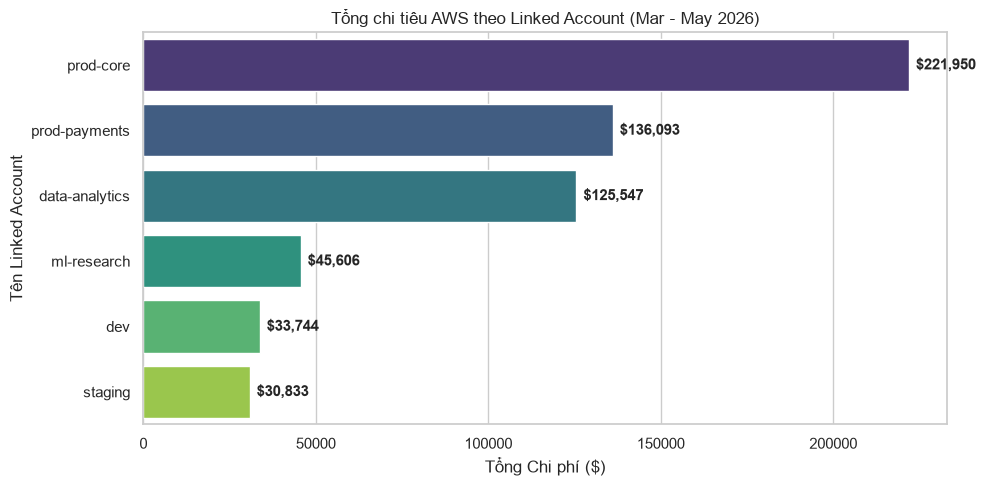

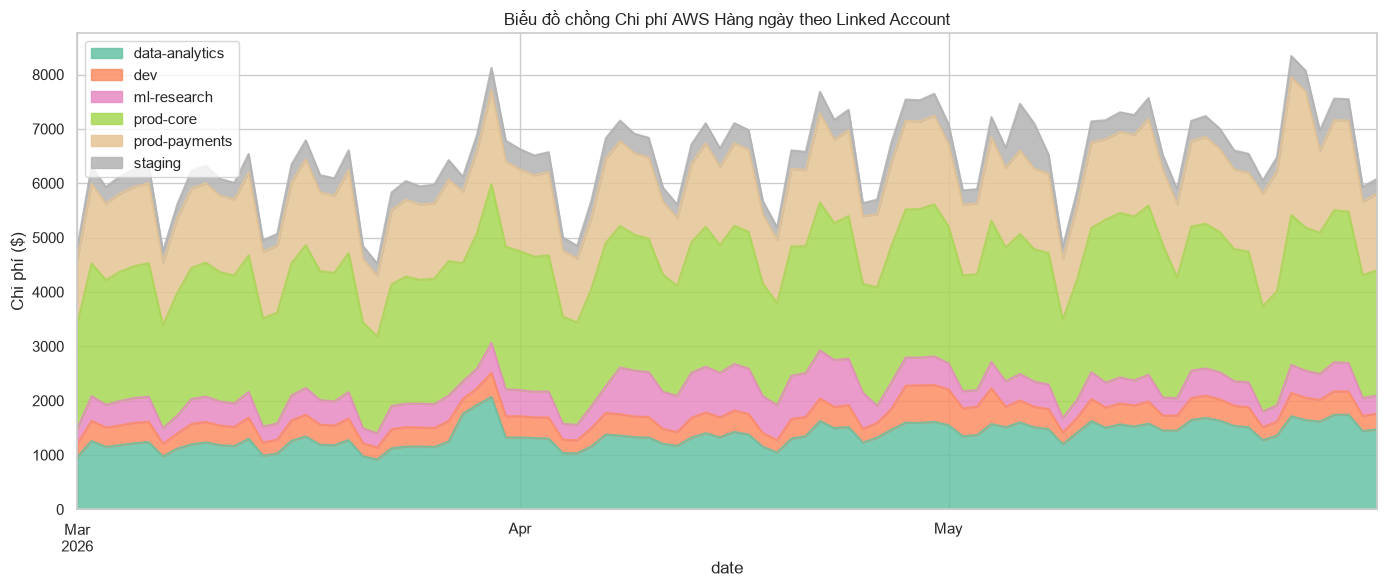

In [5]:
account_spend = df_ce.groupby("linked_account_name")["unblended_cost"].sum().sort_values(ascending=False).reset_index()

plt.figure(figsize=(10, 5))
sns.barplot(data=account_spend, x="unblended_cost", y="linked_account_name", hue="linked_account_name", legend=False, palette="viridis")
plt.title("Tổng chi tiêu AWS theo Linked Account (Mar - May 2026)")
plt.xlabel("Tổng Chi phí ($)")
plt.ylabel("Tên Linked Account")
for idx, row in account_spend.iterrows():
    plt.text(row["unblended_cost"] + 2000, idx, f"${row['unblended_cost']:,.0f}", va="center", fontweight="bold")
plt.tight_layout()
plt.show()

# Biểu đồ chồng chi phí theo ngày của các account
daily_acct = df_ce.pivot_table(index="date", columns="linked_account_name", values="unblended_cost", aggfunc="sum").fillna(0)
daily_acct.plot(kind="area", stacked=True, figsize=(14, 6), colormap="Set2", alpha=0.85)
plt.title("Biểu đồ chồng Chi phí AWS Hàng ngày theo Linked Account")
plt.ylabel("Chi phí ($)")
plt.legend(loc="upper left")
plt.tight_layout()
plt.show()

### 4.3 Phân bổ Chi phí theo Dịch vụ AWS (Service)
Nhóm và so sánh tỷ trọng chi tiêu của các dịch vụ AWS hàng đầu trong tổ chức.

Top các dịch vụ AWS tiêu dùng nhiều nhất:
                                  service unblended_cost percentage
   Amazon Elastic Compute Cloud - Compute    $148,965.52     25.09%
            Amazon Simple Storage Service    $117,927.20     19.86%
                          Amazon DynamoDB     $77,244.04     13.01%
                        AWS Data Transfer     $75,076.12     12.64%
       Amazon Relational Database Service     $63,645.75     10.72%
                         AmazonCloudWatch     $45,603.25      7.68%
                               AWS Lambda     $13,683.02      2.30%
Amazon Managed Streaming for Apache Kafka     $11,905.10      2.00%
                Amazon OpenSearch Service      $9,938.46      1.67%
                       Amazon ElastiCache      $7,731.43      1.30%


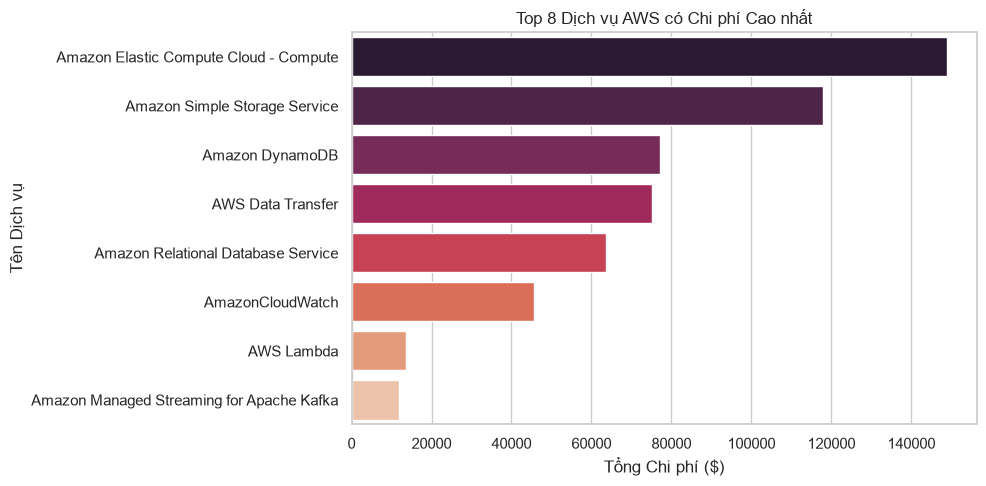

In [6]:
service_spend = df_ce.groupby("service")["unblended_cost"].sum().sort_values(ascending=False).reset_index()
service_spend["percentage"] = (service_spend["unblended_cost"] / service_spend["unblended_cost"].sum()) * 100

print("Top các dịch vụ AWS tiêu dùng nhiều nhất:")
print(service_spend.head(10).to_string(index=False, formatters={"unblended_cost": "${:,.2f}".format, "percentage": "{:.2f}%".format}))

plt.figure(figsize=(10, 5))
sns.barplot(data=service_spend.head(8), x="unblended_cost", y="service", hue="service", legend=False, palette="rocket")
plt.title("Top 8 Dịch vụ AWS có Chi phí Cao nhất")
plt.xlabel("Tổng Chi phí ($)")
plt.ylabel("Tên Dịch vụ")
plt.tight_layout()
plt.show()

### 4.4 Phân tích tỷ lệ Gắn Tag (Resource Tags) trong CUR
Khảo sát chi tiết tỷ trọng chi phí gắn thẻ team (`resource_tags_user_team`).

Bảng chi tiết tiêu dùng theo Team Tag:
                team_tag line_item_unblended_cost percentage
                platform              $186,780.98     31.46%
                data-eng              $125,546.80     21.14%
                payments               $47,171.65      7.94%
                      ml               $45,606.50      7.68%
                     sre               $44,736.89      7.53%
                   fraud               $39,487.53      6.65%
                     web               $27,264.22      4.59%
                  ledger               $23,647.63      3.98%
              onboarding               $15,522.00      2.61%
Không gắn Tag (Untagged)               $13,606.23      2.29%
              mobile-api               $12,223.23      2.06%
                     kyc               $12,179.68      2.05%


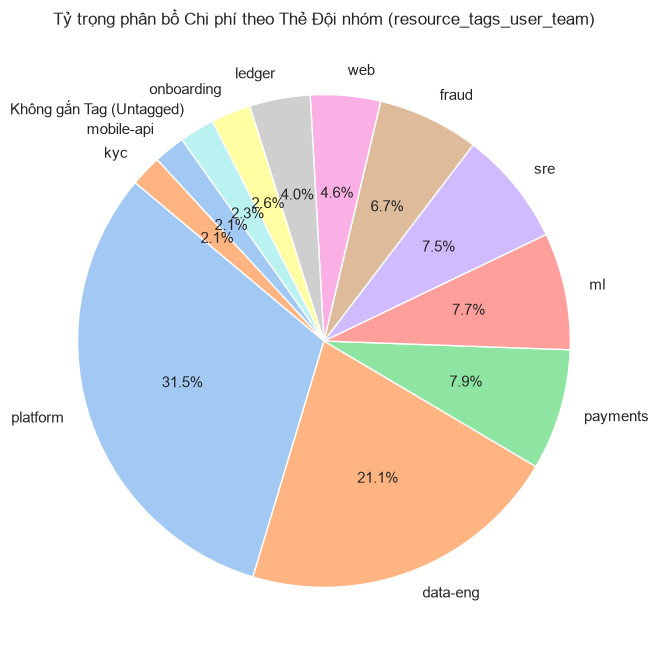

In [7]:
df_cur["team_tag"] = df_cur["resource_tags_user_team"].fillna("Không gắn Tag (Untagged)")
df_cur.loc[df_cur["team_tag"] == "", "team_tag"] = "Không gắn Tag (Untagged)"

tag_spend = df_cur.groupby("team_tag")["line_item_unblended_cost"].sum().sort_values(ascending=False).reset_index()
tag_spend["percentage"] = (tag_spend["line_item_unblended_cost"] / tag_spend["line_item_unblended_cost"].sum()) * 100

print("Bảng chi tiết tiêu dùng theo Team Tag:")
print(tag_spend.to_string(index=False, formatters={"line_item_unblended_cost": "${:,.2f}".format, "percentage": "{:.2f}%".format}))

plt.figure(figsize=(8, 8))
plt.pie(tag_spend["line_item_unblended_cost"], labels=tag_spend["team_tag"], autopct='%1.1f%%', startangle=140, colors=sns.color_palette("pastel"))
plt.title("Tỷ trọng phân bổ Chi phí theo Thẻ Đội nhóm (resource_tags_user_team)")
plt.show()

## 5. Khám phá Dữ liệu Metric Hiệu năng (`metrics_haikhoa`)
Chuyển sang khảo sát các tập dữ liệu metric hiệu năng của tài nguyên hệ thống. Mỗi bản ghi tương ứng với một ngày sử dụng của một tài nguyên xác định.

### 5.1 Phân bố các Nhãn (Label) theo loại Dịch vụ
Xem số lượng dòng dữ liệu và tỷ lệ nhãn cho từng nhóm dịch vụ chính.

In [8]:
metrics_summary = []
for name, df in [("EC2", df_m_ec2), ("RDS", df_m_rds), ("DynamoDB", df_m_ddb), ("SageMaker", df_m_sm), ("Khác", df_m_other)]:
    vc = df["label"].value_counts().to_dict()
    metrics_summary.append({
        "Nhóm Dịch vụ": name,
        "Số dòng": df.shape[0],
        "Số tài nguyên": df["resource_id"].nunique(),
        "Nhãn Normal": vc.get("normal", 0),
        "Nhãn Anomaly": vc.get("anomaly", 0),
        "Nhãn Benign": vc.get("benign", 0)
    })
df_met_sum = pd.DataFrame(metrics_summary)
print(df_met_sum.to_string(index=False))

Nhóm Dịch vụ  Số dòng  Số tài nguyên  Nhãn Normal  Nhãn Anomaly  Nhãn Benign
         EC2    10308            118         8381          1006          921
         RDS     1545             17         1045           256          244
    DynamoDB      245              3          184            61            0
   SageMaker     1104             12          799           122          183
        Khác    11331            126        10462           378          491


### 5.2 Khảo sát Phân phối các Chỉ số hiệu năng (CPU, Memory, DB Connections)
Trực quan hóa phân phối của các metric chính theo nhãn để xem sự khác biệt về mặt hiệu năng giữa nhóm bình thường và bất thường.

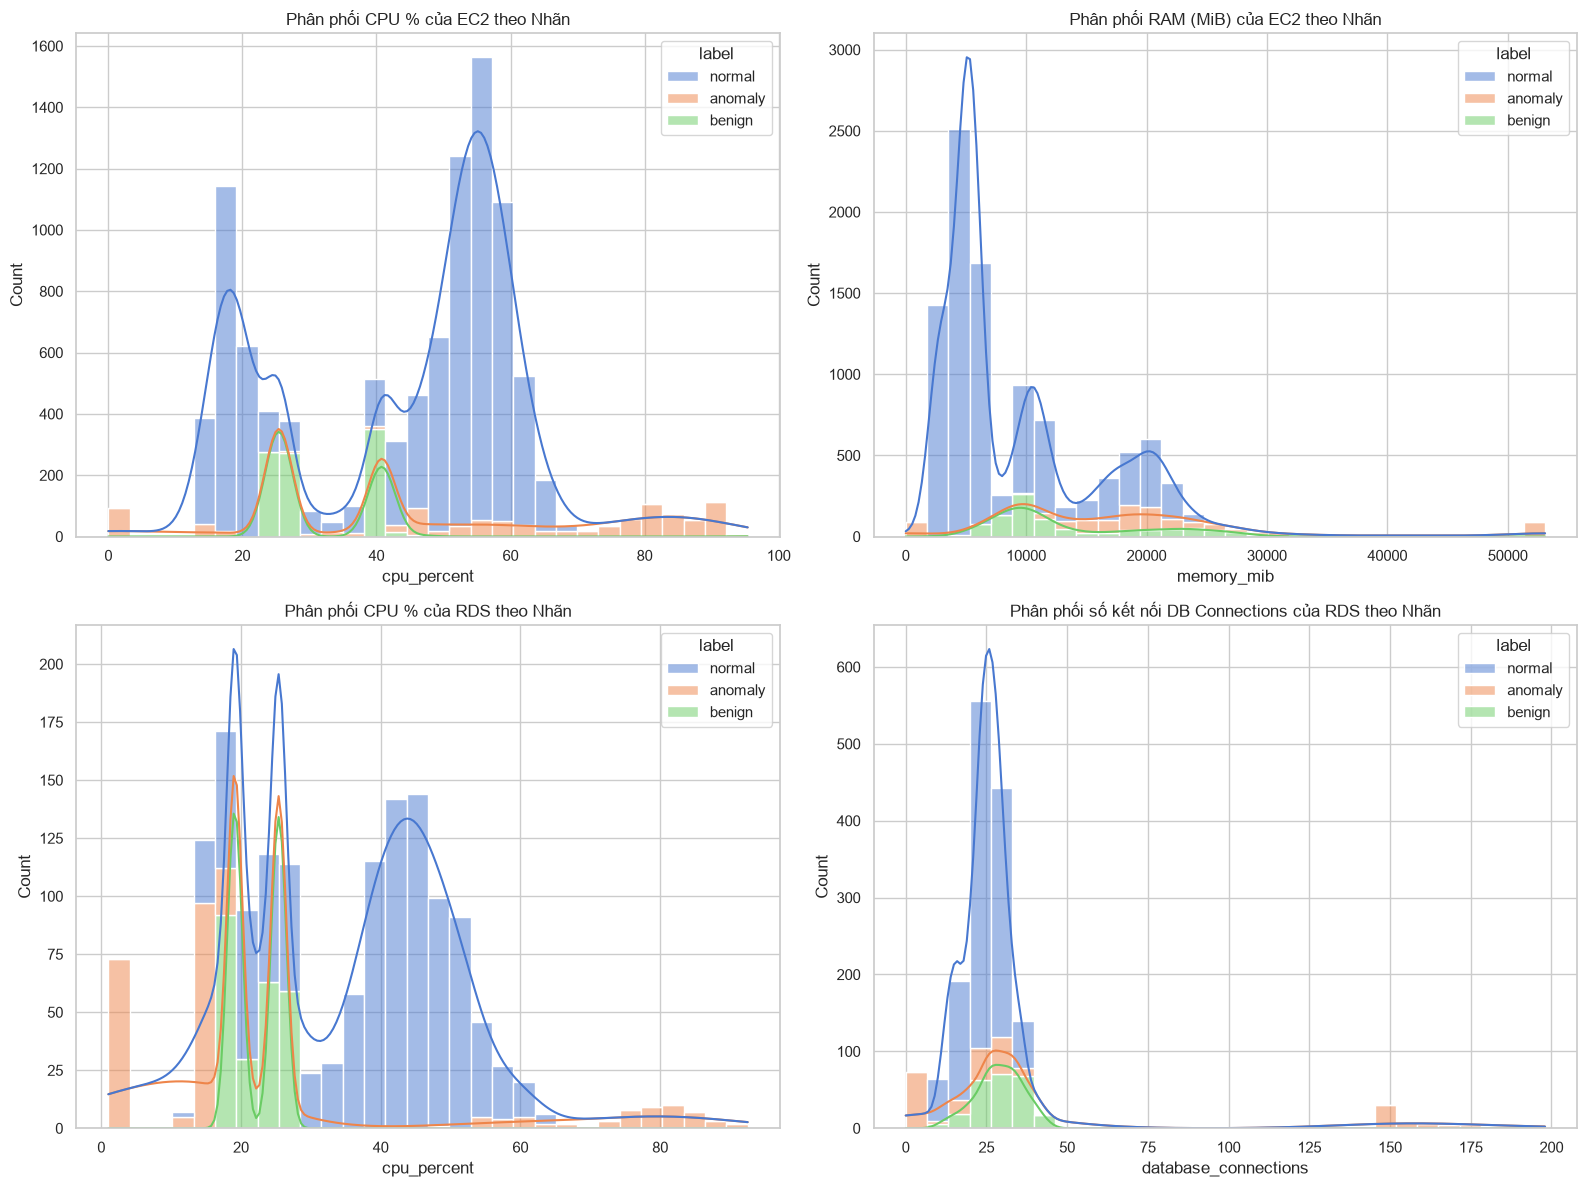

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Phân phối CPU của EC2
sns.histplot(data=df_m_ec2, x="cpu_percent", hue="label", kde=True, ax=axes[0,0], bins=30, multiple="stack")
axes[0,0].set_title("Phân phối CPU % của EC2 theo Nhãn")

# Phân phối RAM của EC2
sns.histplot(data=df_m_ec2, x="memory_mib", hue="label", kde=True, ax=axes[0,1], bins=30, multiple="stack")
axes[0,1].set_title("Phân phối RAM (MiB) của EC2 theo Nhãn")

# Phân phối CPU của RDS
sns.histplot(data=df_m_rds, x="cpu_percent", hue="label", kde=True, ax=axes[1,0], bins=30, multiple="stack")
axes[1,0].set_title("Phân phối CPU % của RDS theo Nhãn")

# Phân phối DB Connections của RDS
sns.histplot(data=df_m_rds, x="database_connections", hue="label", kde=True, ax=axes[1,1], bins=30, multiple="stack")
axes[1,1].set_title("Phân phối số kết nối DB Connections của RDS theo Nhãn")

plt.tight_layout()
plt.show()

## 6. Phân tích Phân phối Dữ liệu giữa các Lớp (Class Distributions & Separability)
Phần này đi sâu khảo sát phân phối của các biến số hiệu năng phân nhóm theo các lớp mục tiêu (`normal`, `anomaly`, `benign`) để xác lập mức độ khác biệt hành vi hoạt động và khả năng phân tách của các đặc trưng.

=== 6.1 THỐNG KÊ MÔ TẢ ĐẶC TRƯNG PHÂN NHÓM THEO LỚP (DESCRIPTIVE STATISTICS BY CLASS) ===

--- 1. Thống kê trị trung bình của dịch vụ EC2 theo Lớp:
         cpu_percent    memory_mib  network_in_bytes  network_out_bytes    disk_io_ops  gpu_utilization
label                                                                                                  
anomaly    59.319133  21787.324292      1.254242e+09       9.188134e+08  140761.642390        91.889461
benign     31.709323  13388.780082      7.134202e+08       3.387008e+08  177832.865196              NaN
normal     43.788037   8050.995650      9.990679e+07       1.198717e+08   19968.033955              NaN

--- 2. Thống kê trị trung bình của dịch vụ RDS theo Lớp:
         cpu_percent    memory_mib  network_in_bytes  network_out_bytes    disk_io_ops  database_connections
label                                                                                                       
anomaly    25.309042  40121.917680      6.357234e+08    

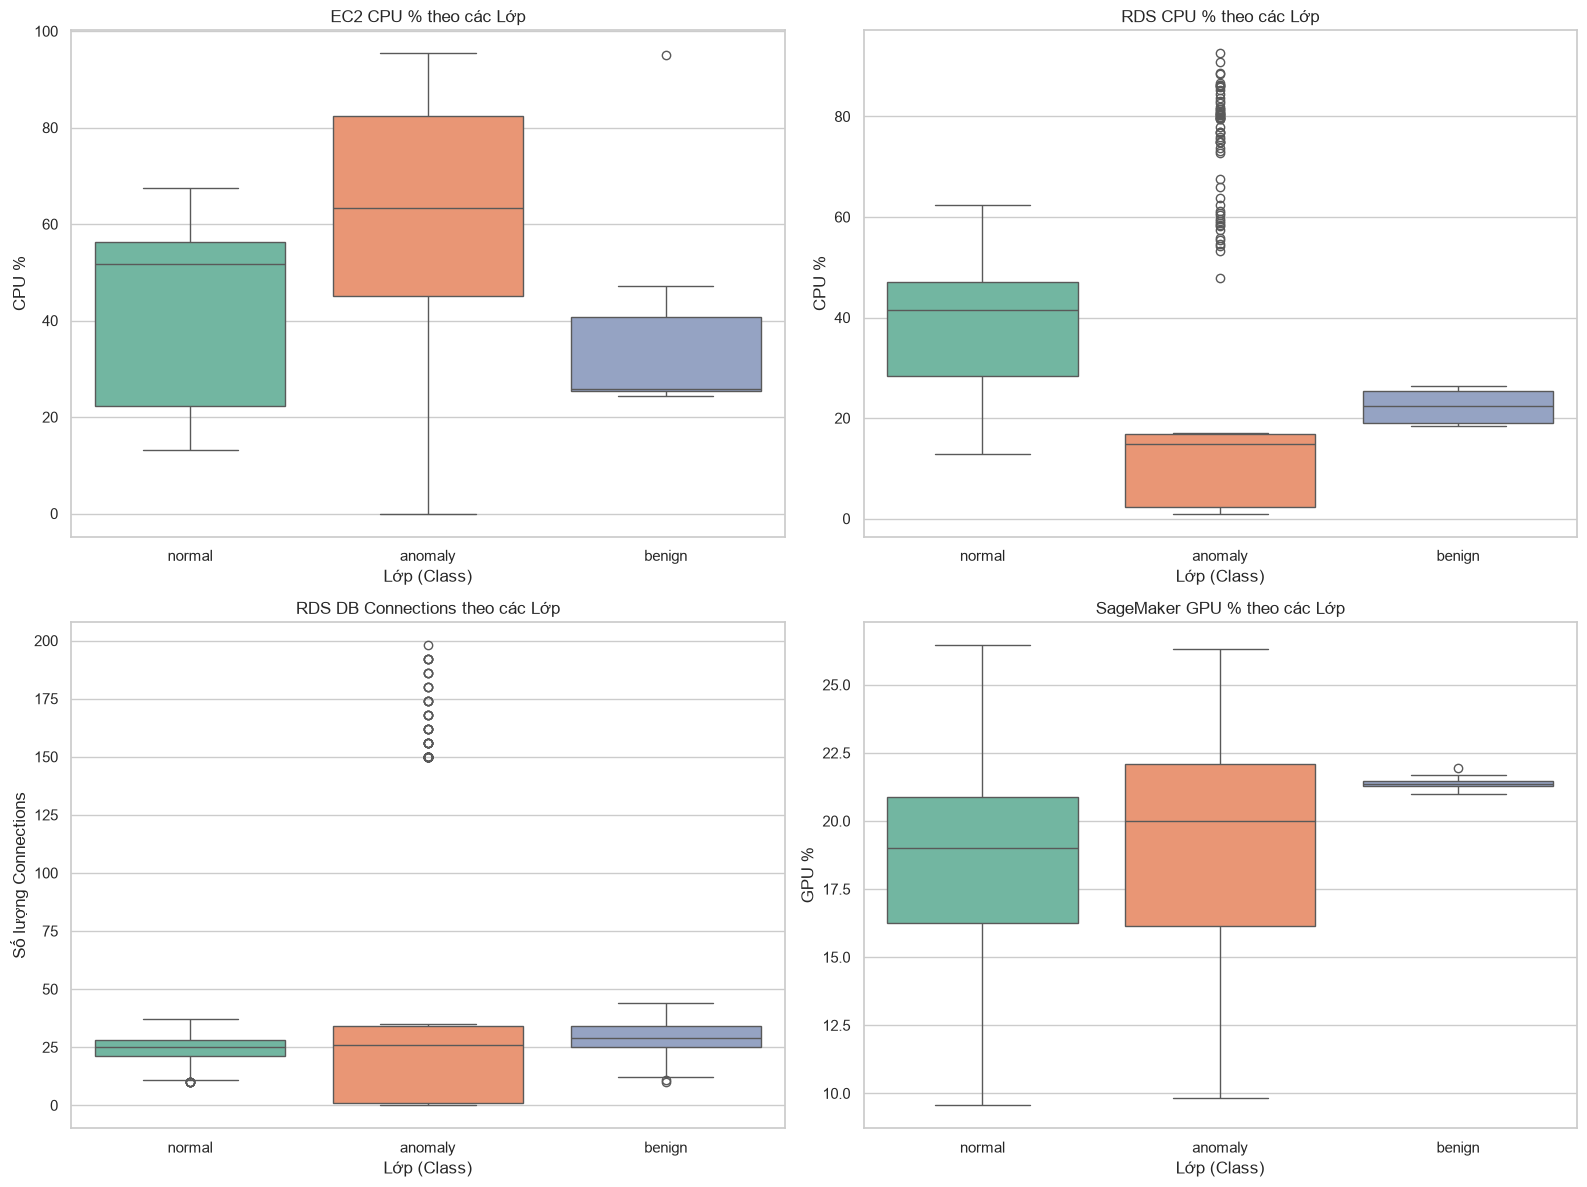

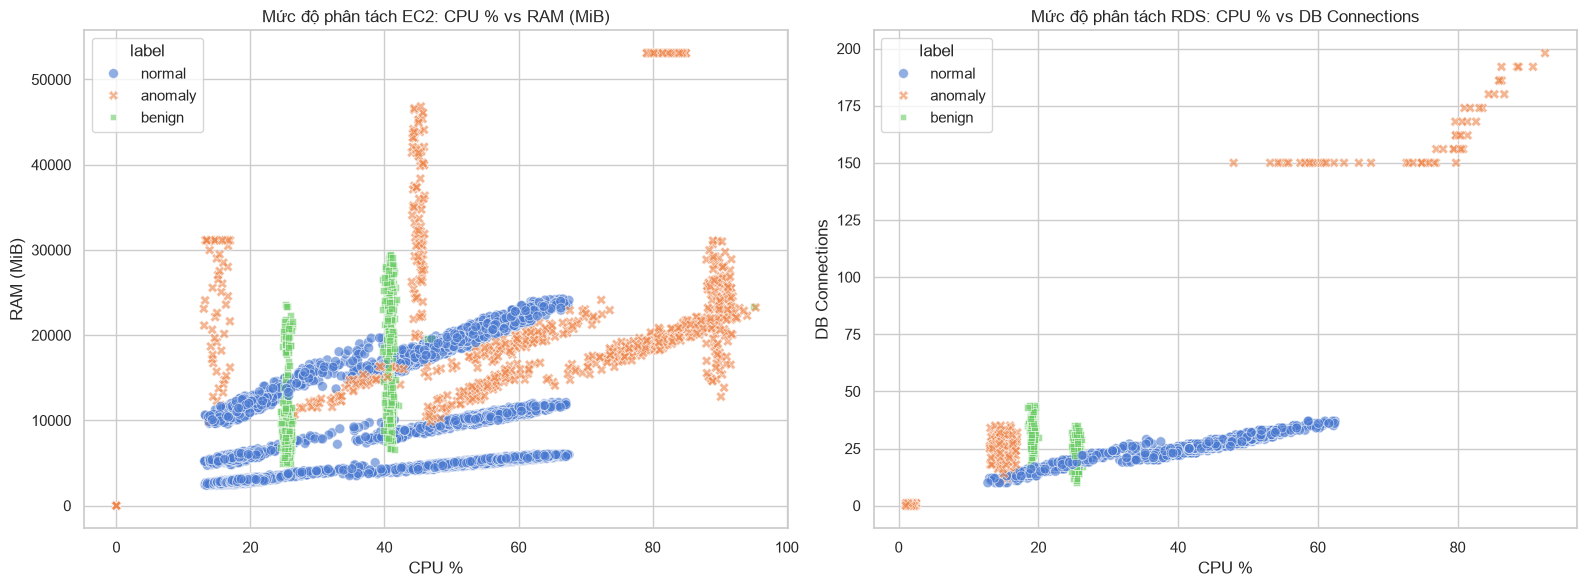

In [10]:
print("=== 6.1 THỐNG KÊ MÔ TẢ ĐẶC TRƯNG PHÂN NHÓM THEO LỚP (DESCRIPTIVE STATISTICS BY CLASS) ===")

ec2_features = ["cpu_percent", "memory_mib", "network_in_bytes", "network_out_bytes", "disk_io_ops", "gpu_utilization"]
print("\n--- 1. Thống kê trị trung bình của dịch vụ EC2 theo Lớp:")
print(df_m_ec2.groupby("label")[ec2_features].mean().to_string())

rds_features = ["cpu_percent", "memory_mib", "network_in_bytes", "network_out_bytes", "disk_io_ops", "database_connections"]
print("\n--- 2. Thống kê trị trung bình của dịch vụ RDS theo Lớp:")
print(df_m_rds.groupby("label")[rds_features].mean().to_string())

sm_features = ["cpu_percent", "memory_mib", "network_in_bytes", "network_out_bytes", "disk_io_ops", "gpu_utilization"]
print("\n--- 3. Thống kê trị trung bình của dịch vụ SageMaker theo Lớp:")
print(df_m_sm.groupby("label")[sm_features].mean().to_string())

# 2. Biểu đồ Boxplot so sánh phân phối giữa các Class
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# EC2 CPU %
sns.boxplot(data=df_m_ec2, x="label", y="cpu_percent", ax=axes[0,0], palette="Set2")
axes[0,0].set_title("EC2 CPU % theo các Lớp")
axes[0,0].set_xlabel("Lớp (Class)")
axes[0,0].set_ylabel("CPU %")

# RDS CPU %
sns.boxplot(data=df_m_rds, x="label", y="cpu_percent", ax=axes[0,1], palette="Set2")
axes[0,1].set_title("RDS CPU % theo các Lớp")
axes[0,1].set_xlabel("Lớp (Class)")
axes[0,1].set_ylabel("CPU %")

# RDS DB Connections
sns.boxplot(data=df_m_rds, x="label", y="database_connections", ax=axes[1,0], palette="Set2")
axes[1,0].set_title("RDS DB Connections theo các Lớp")
axes[1,0].set_xlabel("Lớp (Class)")
axes[1,0].set_ylabel("Số lượng Connections")

# SageMaker GPU Utilization
sns.boxplot(data=df_m_sm, x="label", y="gpu_utilization", ax=axes[1,1], palette="Set2")
axes[1,1].set_title("SageMaker GPU % theo các Lớp")
axes[1,1].set_xlabel("Lớp (Class)")
axes[1,1].set_ylabel("GPU %")

plt.tight_layout()
plt.show()

# 3. Biểu đồ Scatter Plot khảo sát tính phân tách lớp (Separability)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# EC2: CPU % vs RAM
sns.scatterplot(data=df_m_ec2, x="cpu_percent", y="memory_mib", hue="label", style="label", alpha=0.6, ax=axes[0], s=50)
axes[0].set_title("Mức độ phân tách EC2: CPU % vs RAM (MiB)")
axes[0].set_xlabel("CPU %")
axes[0].set_ylabel("RAM (MiB)")

# RDS: CPU % vs DB Connections
sns.scatterplot(data=df_m_rds, x="cpu_percent", y="database_connections", hue="label", style="label", alpha=0.6, ax=axes[1], s=50)
axes[1].set_title("Mức độ phân tách RDS: CPU % vs DB Connections")
axes[1].set_xlabel("CPU %")
axes[1].set_ylabel("DB Connections")

plt.tight_layout()
plt.show()

## 7. Phân tích Tương quan & Trực quan hóa Giá trị Ngoại lai (Outliers)
Thực hiện đo lường ma trận tương quan giữa các biến số số học để tìm mối liên hệ, đồng thời thống kê số lượng bản ghi ngoại lai (đột biến).

=== 7.1 MA TRẬN TƯƠNG QUAN ĐẦY ĐỦ (CORRELATION MATRIX) ===


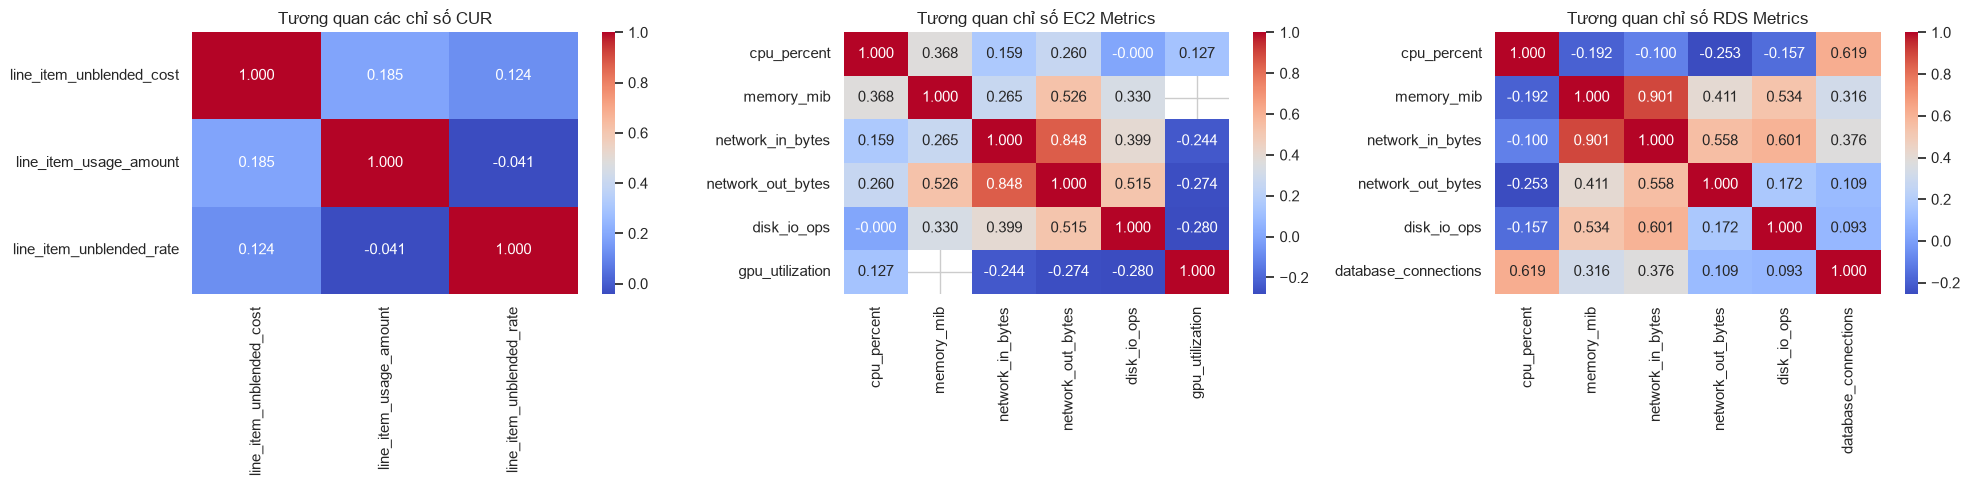


--- In cụ thể các Hệ số tương quan (Correlation Coefficients) ---
1. Tương quan EC2 (Chi phí hàng ngày vs CPU trung bình %):
                          line_item_unblended_cost  cpu_percent
line_item_unblended_cost                  1.000000     0.107829
cpu_percent                               0.107829     1.000000

2. Tương quan RDS (Chi phí hàng ngày vs CPU trung bình %):
                          line_item_unblended_cost  cpu_percent
line_item_unblended_cost                  1.000000    -0.101638
cpu_percent                              -0.101638     1.000000

3. Tương quan RDS (Chi phí hàng ngày vs Số kết nối Database Connections):
                          line_item_unblended_cost  database_connections
line_item_unblended_cost                  1.000000              0.374066
database_connections                      0.374066              1.000000

=== 7.2 THỐNG KÊ GIÁ TRỊ NGOẠI LAI (OUTLIER STATISTICS - PHƯƠNG PHÁP IQR) ===
     Bộ dữ liệu               Cột chỉ số  Q1 (25%)  Q3 (7

In [11]:
print("=== 7.1 MA TRẬN TƯƠNG QUAN ĐẦY ĐỦ (CORRELATION MATRIX) ===")
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Tương quan dữ liệu chi phí CUR (chỉ lấy thuộc tính số học)
cur_num_cols = ["line_item_unblended_cost", "line_item_usage_amount", "line_item_unblended_rate"]
sns.heatmap(df_cur[cur_num_cols].corr(), annot=True, cmap="coolwarm", fmt=".3f", ax=axes[0])
axes[0].set_title("Tương quan các chỉ số CUR")

# Tương quan chỉ số EC2 Metrics
ec2_num_cols = ["cpu_percent", "memory_mib", "network_in_bytes", "network_out_bytes", "disk_io_ops", "gpu_utilization"]
sns.heatmap(df_m_ec2[ec2_num_cols].corr(), annot=True, cmap="coolwarm", fmt=".3f", ax=axes[1])
axes[1].set_title("Tương quan chỉ số EC2 Metrics")

# Tương quan chỉ số RDS Metrics
rds_num_cols = ["cpu_percent", "memory_mib", "network_in_bytes", "network_out_bytes", "disk_io_ops", "database_connections"]
sns.heatmap(df_m_rds[rds_num_cols].corr(), annot=True, cmap="coolwarm", fmt=".3f", ax=axes[2])
axes[2].set_title("Tương quan chỉ số RDS Metrics")

plt.tight_layout()
plt.show()

# Chuẩn bị dữ liệu merge để tính correlation coefficients cụ thể
cur_daily = df_cur.groupby(["line_item_usage_start_date", "line_item_resource_id", "line_item_product_code"])["line_item_unblended_cost"].sum().reset_index()
cur_daily.rename(columns={"line_item_usage_start_date": "date", "line_item_resource_id": "resource_id", "line_item_product_code": "product_code"}, inplace=True)
rds_merged = pd.merge(df_m_rds, cur_daily, left_on=["timestamp", "resource_id"], right_on=["date", "resource_id"])
ec2_merged = pd.merge(df_m_ec2, cur_daily, left_on=["timestamp", "resource_id"], right_on=["date", "resource_id"])

print("\n--- In cụ thể các Hệ số tương quan (Correlation Coefficients) ---")
corr_ec2 = ec2_merged[['line_item_unblended_cost', 'cpu_percent']].corr()
print("1. Tương quan EC2 (Chi phí hàng ngày vs CPU trung bình %):")
print(corr_ec2)

corr_rds_cpu = rds_merged[['line_item_unblended_cost', 'cpu_percent']].corr()
print("\n2. Tương quan RDS (Chi phí hàng ngày vs CPU trung bình %):")
print(corr_rds_cpu)

corr_rds_conn = rds_merged[['line_item_unblended_cost', 'database_connections']].corr()
print("\n3. Tương quan RDS (Chi phí hàng ngày vs Số kết nối Database Connections):")
print(corr_rds_conn)

print("\n=== 7.2 THỐNG KÊ GIÁ TRỊ NGOẠI LAI (OUTLIER STATISTICS - PHƯƠNG PHÁP IQR) ===")
outlier_list = []

def get_outliers_info(df, column, df_name):
    q1 = df[column].quantile(0.25)
    q3 = df[column].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    outlier_list.append({
        "Bộ dữ liệu": df_name,
        "Cột chỉ số": column,
        "Q1 (25%)": q1,
        "Q3 (75%)": q3,
        "Ngưỡng Dưới": lower_bound,
        "Ngưỡng Trên": upper_bound,
        "Số Outliers": len(outliers),
        "Tỷ lệ Outliers (%)": len(outliers) / len(df) * 100
    })

# Tính Outliers trên một số đặc trưng cốt lõi
get_outliers_info(df_cur, "line_item_unblended_cost", "CUR Cost")
get_outliers_info(df_m_ec2, "cpu_percent", "EC2 CPU %")
get_outliers_info(df_m_rds, "cpu_percent", "RDS CPU %")
get_outliers_info(df_m_rds, "database_connections", "RDS Connections")

df_outliers = pd.DataFrame(outlier_list)
print(df_outliers.to_string(index=False))

## 8. Phân tích Trôi dạt Dữ liệu theo Thời gian (Data Drift Analysis)
Trôi dạt dữ liệu xảy ra khi phân phối của các biến số học thay đổi đáng kể theo thời gian. Chúng ta sẽ so sánh dữ liệu giữa **Tháng 3 (tháng đầu tiên)** và **Tháng 5 (tháng cuối cùng)** và sử dụng kiểm định Kolmogorov-Smirnov (KS-test) để đánh giá độ trôi dạt một cách khoa học.

=== 8.1 PHÂN TÍCH TRÔI DẠT DỮ LIỆU THÁNG 3 VS THÁNG 5 ===
               Chỉ số  Tháng 3 Mean  Tháng 5 Mean  Tháng 3 Std Dev  Tháng 5 Std Dev  KS Statistic      p-value Bị trôi dạt (Drifted)?
   Chi phí CUR (Cost)     22.784009     25.527996        70.922165        78.501332      0.025423 9.555073e-03          CÓ (p < 0.05)
EC2 CPU % Utilization     41.752025     44.691422        15.772868        19.593616      0.237274 1.427454e-85          CÓ (p < 0.05)
RDS CPU % Utilization     36.137929     33.047356        12.121527        18.558957      0.303086 1.700907e-21          CÓ (p < 0.05)
   RDS DB Connections     22.557087     33.102467         6.334114        33.478626      0.312966 6.511543e-23          CÓ (p < 0.05)


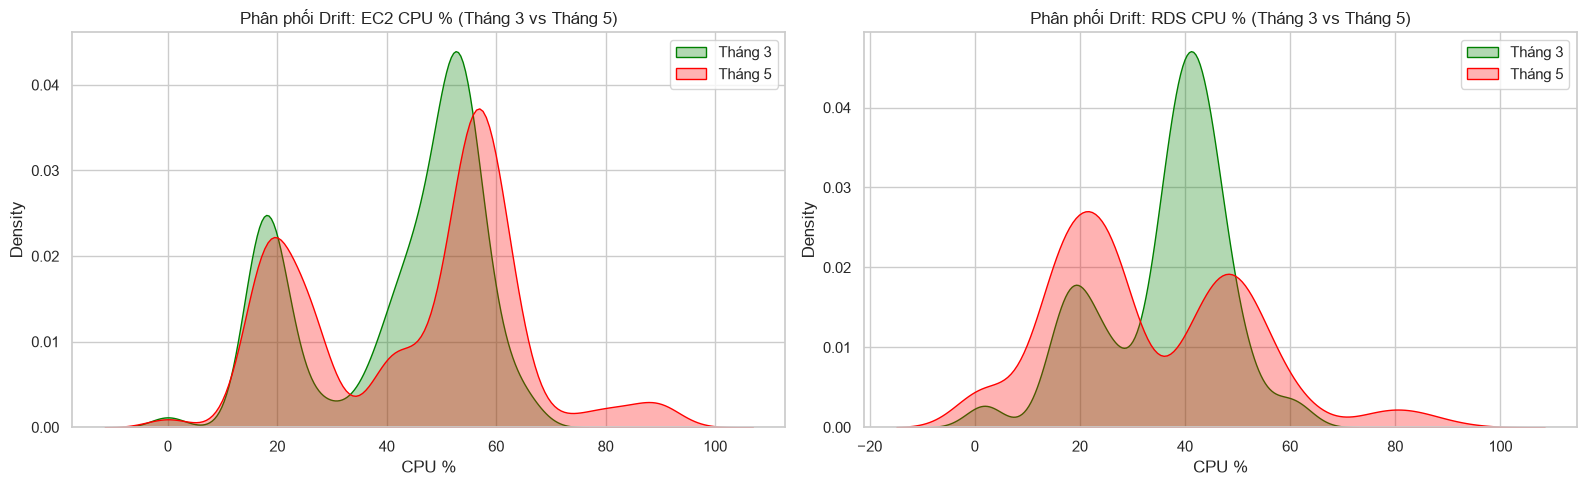

In [12]:
print("=== 8.1 PHÂN TÍCH TRÔI DẠT DỮ LIỆU THÁNG 3 VS THÁNG 5 ===")

drift_features = [
    (df_cur, "line_item_unblended_cost", "line_item_usage_start_date", "Chi phí CUR (Cost)"),
    (df_m_ec2, "cpu_percent", "timestamp", "EC2 CPU % Utilization"),
    (df_m_rds, "cpu_percent", "timestamp", "RDS CPU % Utilization"),
    (df_m_rds, "database_connections", "timestamp", "RDS DB Connections")
]

drift_results = []
for df, col, time_col, feature_name in drift_features:
    m3 = df[df[time_col].dt.month == 3][col].dropna()
    m5 = df[df[time_col].dt.month == 5][col].dropna()
    
    if len(m3) > 0 and len(m5) > 0:
        stat, p_val = ks_2samp(m3, m5)
        drifted = p_val < 0.05
        drift_results.append({
            "Chỉ số": feature_name,
            "Tháng 3 Mean": m3.mean(),
            "Tháng 5 Mean": m5.mean(),
            "Tháng 3 Std Dev": m3.std(),
            "Tháng 5 Std Dev": m5.std(),
            "KS Statistic": stat,
            "p-value": p_val,
            "Bị trôi dạt (Drifted)?": "CÓ (p < 0.05)" if drifted else "Không"
        })

df_drift = pd.DataFrame(drift_results)
print(df_drift.to_string(index=False))

# Trực quan hóa phân phối biến đổi (Drift) bằng biểu đồ KDE
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Biểu đồ trôi dạt EC2 CPU %
sns.kdeplot(df_m_ec2[df_m_ec2["timestamp"].dt.month == 3]["cpu_percent"], label="Tháng 3", fill=True, ax=axes[0], color="green", alpha=0.3)
sns.kdeplot(df_m_ec2[df_m_ec2["timestamp"].dt.month == 5]["cpu_percent"], label="Tháng 5", fill=True, ax=axes[0], color="red", alpha=0.3)
axes[0].set_title("Phân phối Drift: EC2 CPU % (Tháng 3 vs Tháng 5)")
axes[0].set_xlabel("CPU %")
axes[0].legend()

# Biểu đồ trôi dạt RDS CPU %
sns.kdeplot(df_m_rds[df_m_rds["timestamp"].dt.month == 3]["cpu_percent"], label="Tháng 3", fill=True, ax=axes[1], color="green", alpha=0.3)
sns.kdeplot(df_m_rds[df_m_rds["timestamp"].dt.month == 5]["cpu_percent"], label="Tháng 5", fill=True, ax=axes[1], color="red", alpha=0.3)
axes[1].set_title("Phân phối Drift: RDS CPU % (Tháng 3 vs Tháng 5)")
axes[1].set_xlabel("CPU %")
axes[1].legend()

plt.tight_layout()
plt.show()

## 9. Tương quan hóa Chi phí và Metric Hiệu năng
Bản chất cốt lõi của bài toán FinOps Watch là so khớp đồng thời **Chi phí** và **Metric hoạt động**.

In [13]:
print(f"Số dòng RDS sau khi gộp (Cost + Metrics): {rds_merged.shape[0]}")
print(f"Số dòng EC2 sau khi gộp (Cost + Metrics): {ec2_merged.shape[0]}")

Số dòng RDS sau khi gộp (Cost + Metrics): 1545
Số dòng EC2 sau khi gộp (Cost + Metrics): 10308


### 9.2 Biểu đồ tương quan Tỷ lệ sử dụng CPU vs Chi phí hàng ngày
Khảo sát biểu đồ phân tán Scatter Plot giữa CPU phần trăm và chi phí hàng ngày cho các máy ảo EC2.

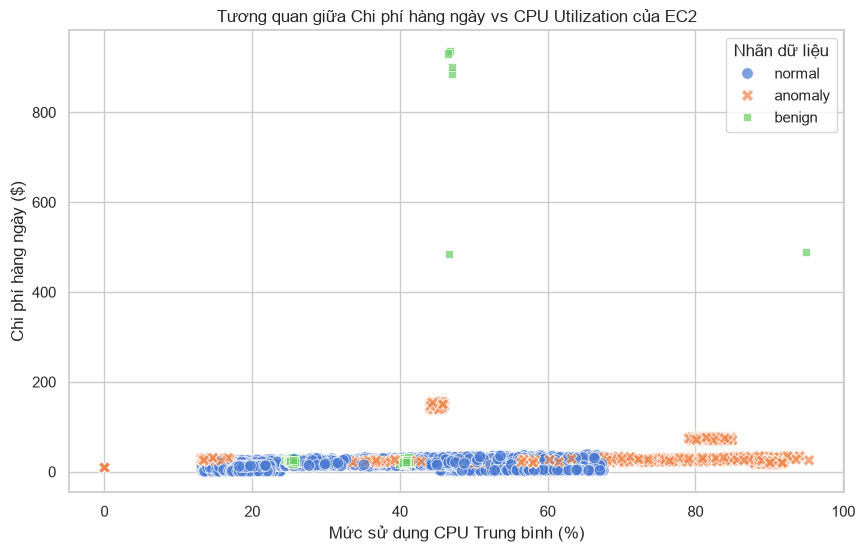

In [14]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=ec2_merged, x="cpu_percent", y="line_item_unblended_cost", hue="label", style="label", alpha=0.7, s=70)
plt.title("Tương quan giữa Chi phí hàng ngày vs CPU Utilization của EC2")
plt.xlabel("Mức sử dụng CPU Trung bình (%)")
plt.ylabel("Chi phí hàng ngày ($)")
plt.legend(title="Nhãn dữ liệu")
plt.show()

## 10. Đi sâu phân tích các mẫu Anomalies và Confounders công khai
Trực quan hóa hoạt động của 3 thực thể đã được dán nhãn công khai trong `anomaly_labels_public.csv`:
- `A2` (Bất thường - Anomaly: Cơ sở dữ liệu RDS nhàn rỗi - idle_resource)
- `A6` (Bất thường - Anomaly: CloudWatch Logs ghi log runaway do debug - sudden_spike)
- `B2` (Sự kiện hợp lệ - Benign: Di chuyển dữ liệu egress theo kế hoạch - benign_event)

### 10.1 Trường hợp A2: Database RDS bị bỏ quên (Idle RDS Database)
**Tài nguyên:** `arn:aws:rds:us-east-1:acct:db:db-staging-orphan-01`
**Mô tả:** Cơ sở dữ liệu RDS instance db.r5.2xlarge chạy liên tục 10+ tuần nhưng gần như không phát sinh kết nối kết nối (database connections ~0), gây lãng phí chi phí.

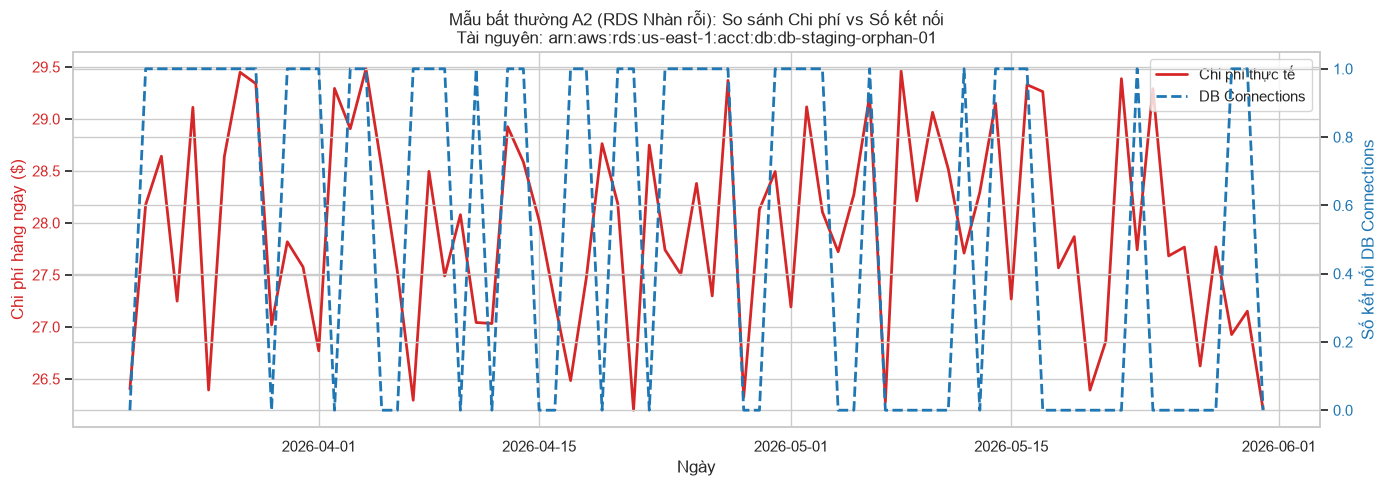

Tổng chi phí lãng phí trên DB này: $2,040.01
CPU trung bình: 1.79%
Số kết nối trung bình: 0.55


In [15]:
a2_res = "arn:aws:rds:us-east-1:acct:db:db-staging-orphan-01"
a2_data = rds_merged[rds_merged["resource_id"] == a2_res].sort_values("date")

fig, ax1 = plt.subplots(figsize=(14, 5))

color = '#d62728'
ax1.set_xlabel('Ngày')
ax1.set_ylabel('Chi phí hàng ngày ($)', color=color)
ax1.plot(a2_data['date'], a2_data['line_item_unblended_cost'], color=color, linewidth=2, label="Chi phí thực tế")
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()
color = '#1f77b4'
ax2.set_ylabel('Số kết nối DB Connections', color=color)
ax2.plot(a2_data['date'], a2_data['database_connections'], color=color, linestyle="--", linewidth=2, label="DB Connections")
ax2.tick_params(axis='y', labelcolor=color)

# Nhúng nhãn chú thích
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")

plt.title(f"Mẫu bất thường A2 (RDS Nhàn rỗi): So sánh Chi phí vs Số kết nối\nTài nguyên: {a2_res}")
fig.tight_layout()
plt.show()

print(f"Tổng chi phí lãng phí trên DB này: ${a2_data['line_item_unblended_cost'].sum():,.2f}")
print(f"CPU trung bình: {a2_data['cpu_percent'].mean():.2f}%")
print(f"Số kết nối trung bình: {a2_data['database_connections'].mean():.2f}")

### 10.2 Trường hợp A6: CloudWatch Logs Ingest Spike (DEBUG Runaway)
**Tài nguyên:** `log-group-debug-runaway`
**Mô tả:** Nhầm lẫn cấu hình bật log debug trên hot Lambda function làm tăng vọt lượng dữ liệu đẩy vào CloudWatch Logs, tăng chi phí đột ngột lên ~$260/ngày trong một tuần.

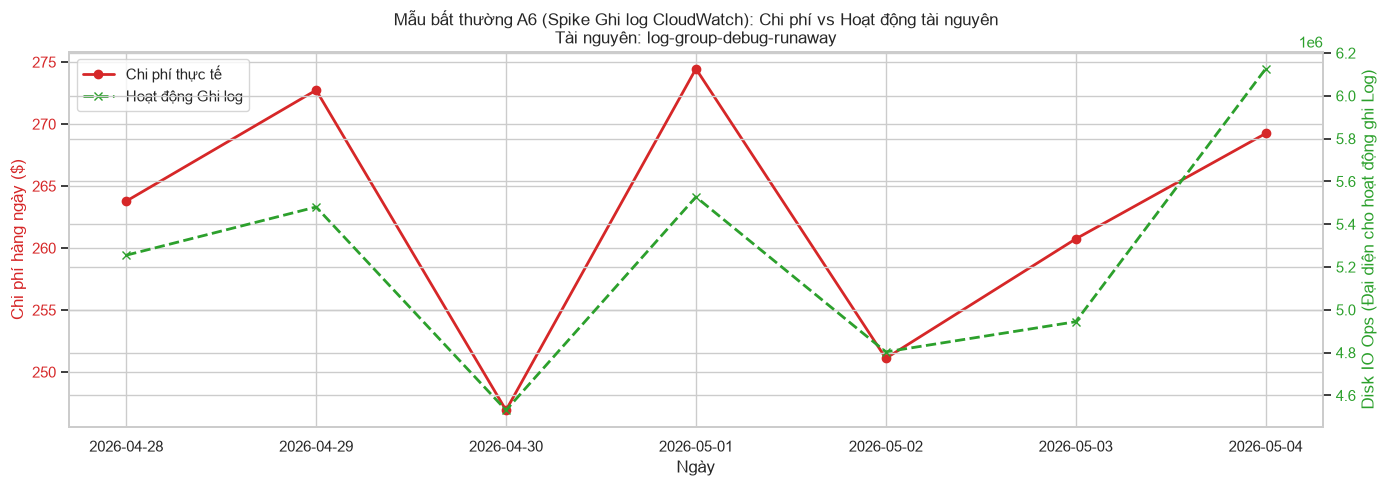

Tổng chi phí phát sinh trong tuần bất thường: $1,838.98


In [16]:
a6_res = "log-group-debug-runaway"
# Merge các dịch vụ Khác với CUR daily
other_merged = pd.merge(df_m_other, cur_daily, left_on=["timestamp", "resource_id"], right_on=["date", "resource_id"])
a6_data = other_merged[other_merged["resource_id"] == a6_res].sort_values("date")

fig, ax1 = plt.subplots(figsize=(14, 5))

color = '#d62728'
ax1.set_xlabel('Ngày')
ax1.set_ylabel('Chi phí hàng ngày ($)', color=color)
ax1.plot(a6_data['date'], a6_data['line_item_unblended_cost'], color=color, marker='o', linewidth=2, label="Chi phí thực tế")
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()
color = '#2ca02c'
ax2.set_ylabel('Disk IO Ops (Đại diện cho hoạt động ghi Log)', color=color)
ax2.plot(a6_data['date'], a6_data['disk_io_ops'], color=color, linestyle="--", marker='x', linewidth=2, label="Hoạt động Ghi log")
ax2.tick_params(axis='y', labelcolor=color)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

plt.title(f"Mẫu bất thường A6 (Spike Ghi log CloudWatch): Chi phí vs Hoạt động tài nguyên\nTài nguyên: {a6_res}")
fig.tight_layout()
plt.show()

print(f"Tổng chi phí phát sinh trong tuần bất thường: ${a6_data['line_item_unblended_cost'].sum():,.2f}")

### 10.3 Trường hợp B2: Di chuyển dữ liệu Migration (Benign Confounder)
**Tài nguyên:** `migration-egress-onetime`
**Mô tả:** Di chuyển dữ liệu sang đối tác đã có kế hoạch trước và được cấp ticket phê duyệt của bộ phận tài chính.

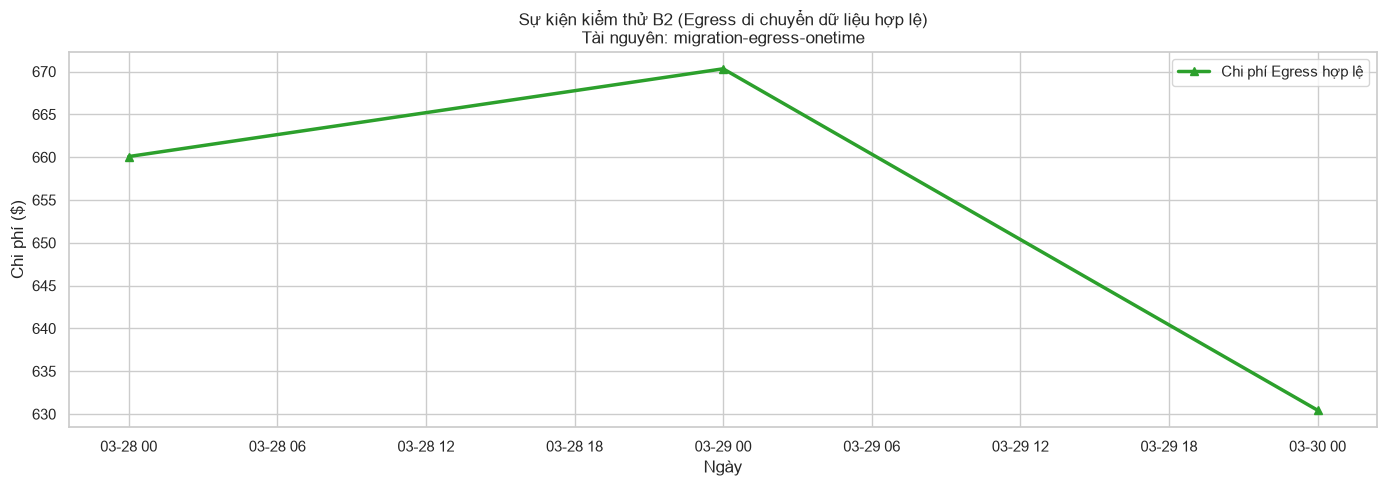

Tổng chi phí di chuyển dữ liệu: $1,960.85


In [17]:
b2_res = "migration-egress-onetime"
b2_data = other_merged[other_merged["resource_id"] == b2_res].sort_values("date")

plt.figure(figsize=(14, 5))
plt.plot(b2_data['date'], b2_data['line_item_unblended_cost'], color='#2ca02c', marker='^', linewidth=2.5, label="Chi phí Egress hợp lệ")
plt.title(f"Sự kiện kiểm thử B2 (Egress di chuyển dữ liệu hợp lệ)\nTài nguyên: {b2_res}")
plt.xlabel("Ngày")
plt.ylabel("Chi phí ($)")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Tổng chi phí di chuyển dữ liệu: ${b2_data['line_item_unblended_cost'].sum():,.2f}")

## 11. Khám phá các Anomalies Ẩn khác trong Bộ dữ liệu
Ngoài 3 mẫu công khai, bộ dữ liệu còn chứa các tài nguyên bất thường khác. Chúng ta sẽ lọc và trực quan hóa chúng dựa trên nhãn dữ liệu.

### 11.1 Trường hợp sử dụng GPU vô tội vạ (Runaway GPU Instances)
Tìm các instance GPU được đánh nhãn anomaly và kiểm tra hành vi hoạt động.

Tìm thấy các máy ảo chạy GPU bất thường: ['i-0fbgpu00000000', 'i-0fbgpu00000001', 'i-0fbgpu00000002', 'i-0fbgpu00000003', 'i-0fbgpu00000004']


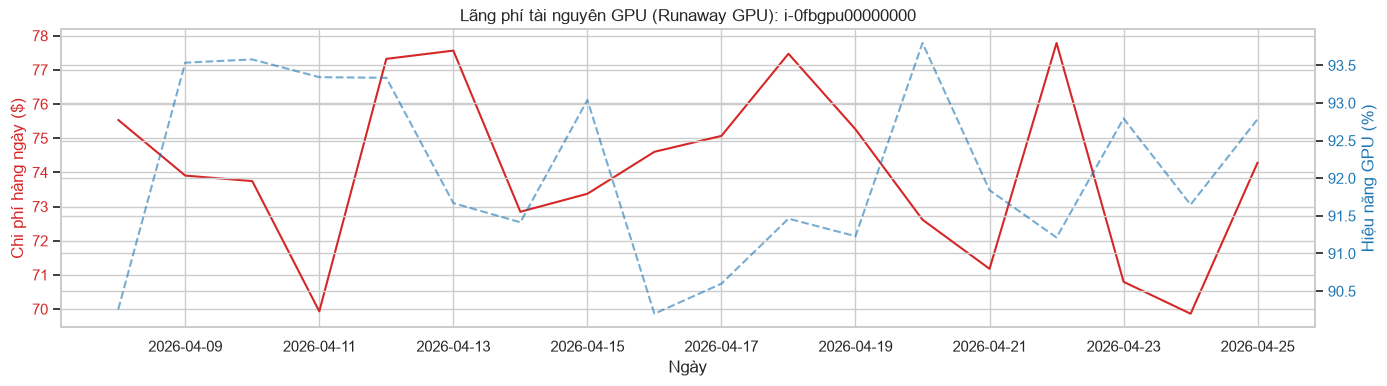

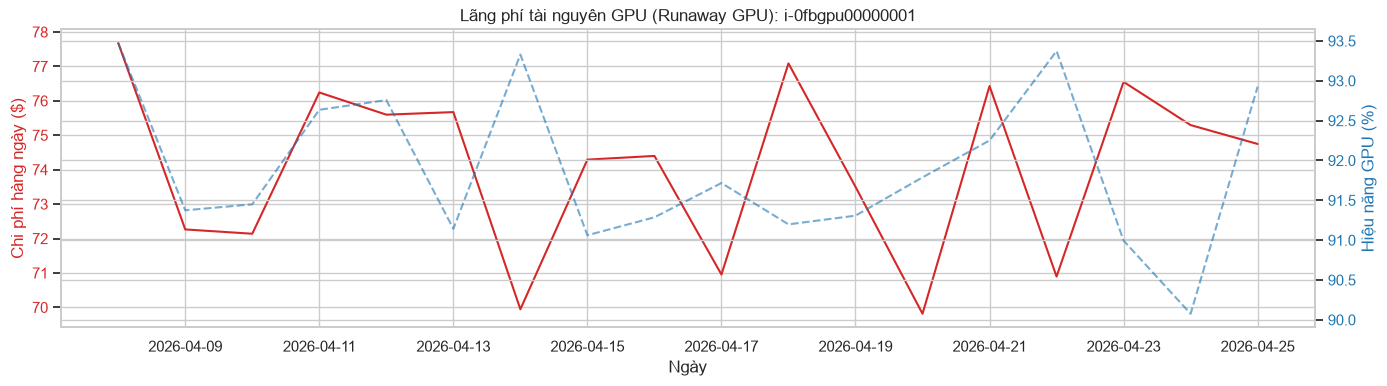

In [18]:
gpu_anomalies = ec2_merged[(ec2_merged["label"] == "anomaly") & (ec2_merged["resource_id"].str.contains("gpu"))]
gpu_res_ids = gpu_anomalies["resource_id"].unique()

print(f"Tìm thấy các máy ảo chạy GPU bất thường: {list(gpu_res_ids)}")

for res in gpu_res_ids[:2]:
    res_data = ec2_merged[ec2_merged["resource_id"] == res].sort_values("date")
    fig, ax1 = plt.subplots(figsize=(14, 4))
    
    color = '#d62728'
    ax1.set_xlabel('Ngày')
    ax1.set_ylabel('Chi phí hàng ngày ($)', color=color)
    ax1.plot(res_data["date"], res_data["line_item_unblended_cost"], color=color, label="Chi phí ($)")
    ax1.tick_params(axis='y', labelcolor=color)
    
    ax2 = ax1.twinx()
    color = '#1f77b4'
    ax2.set_ylabel('Hiệu năng GPU (%)', color=color)
    ax2.plot(res_data["date"], res_data["gpu_utilization"], color=color, alpha=0.6, label="GPU Utilization (%)", linestyle="--")
    ax2.tick_params(axis='y', labelcolor=color)
    
    plt.title(f"Lãng phí tài nguyên GPU (Runaway GPU): {res}")
    fig.tight_layout()
    plt.show()

### 11.2 Untagged Fleet Anomaly
Tài nguyên `i-0untaggedfleet01` bị đánh dấu anomaly liên tục suốt 92 ngày. Hãy kiểm tra xu hướng chi phí của nó.

Tài nguyên không gắn Tag liên tục: i-0untaggedfleet01
Tổng chi phí tích lũy: $13,606.23


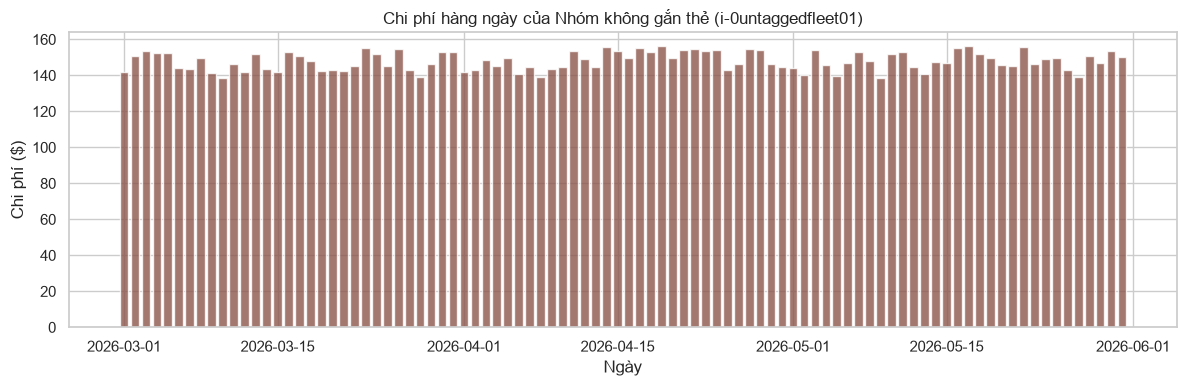

In [19]:
untagged_fleet = ec2_merged[ec2_merged["resource_id"] == "i-0untaggedfleet01"].sort_values("date")
print(f"Tài nguyên không gắn Tag liên tục: i-0untaggedfleet01")
print(f"Tổng chi phí tích lũy: ${untagged_fleet['line_item_unblended_cost'].sum():,.2f}")

plt.figure(figsize=(12, 4))
plt.bar(untagged_fleet["date"], untagged_fleet["line_item_unblended_cost"], color="#8c564b", alpha=0.8)
plt.title("Chi phí hàng ngày của Nhóm không gắn thẻ (i-0untaggedfleet01)")
plt.xlabel("Ngày")
plt.ylabel("Chi phí ($)")
plt.tight_layout()
plt.show()

## 12. Phân tích mẫu CPU hàng giờ (Hourly CPU Utilization Pattern)
Khảo sát hồ sơ sử dụng CPU trong ngày (từ giờ 0 đến giờ 23) của các máy ảo EC2.

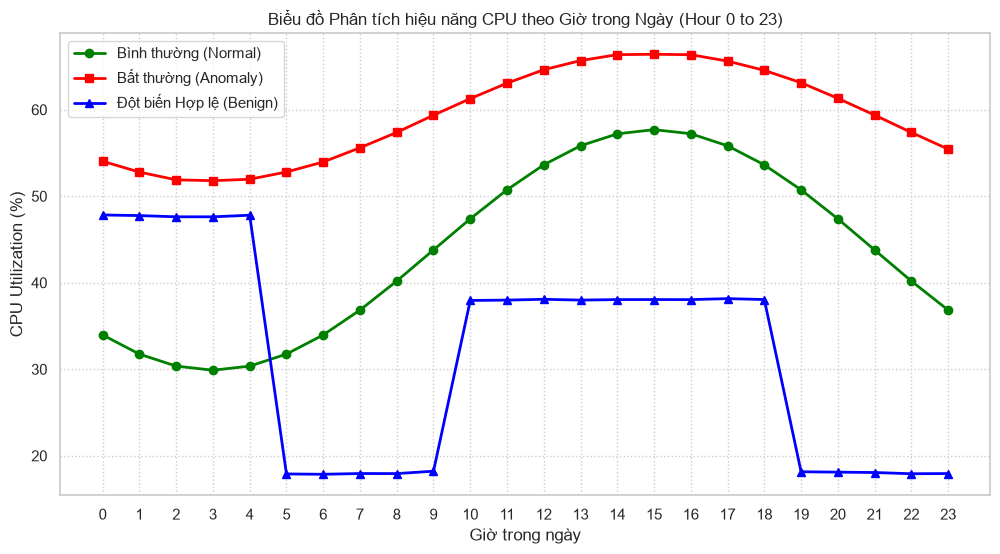

In [20]:
hourly_cols = [f"cpu_h{i}" for i in range(24)]

# Tính giá trị trung bình profile theo giờ cho các nhãn khác nhau
ec2_hourly_normal = df_m_ec2[df_m_ec2["label"] == "normal"][hourly_cols].mean()
ec2_hourly_anomaly = df_m_ec2[df_m_ec2["label"] == "anomaly"][hourly_cols].mean()
ec2_hourly_benign = df_m_ec2[df_m_ec2["label"] == "benign"][hourly_cols].mean()

plt.figure(figsize=(12, 6))
plt.plot(range(24), ec2_hourly_normal, marker="o", label="Bình thường (Normal)", color="green", linewidth=2)
plt.plot(range(24), ec2_hourly_anomaly, marker="s", label="Bất thường (Anomaly)", color="red", linewidth=2)
plt.plot(range(24), ec2_hourly_benign, marker="^", label="Đột biến Hợp lệ (Benign)", color="blue", linewidth=2)
plt.title("Biểu đồ Phân tích hiệu năng CPU theo Giờ trong Ngày (Hour 0 to 23)")
plt.xlabel("Giờ trong ngày")
plt.ylabel("CPU Utilization (%)")
plt.xticks(range(24))
plt.legend()
plt.grid(True, linestyle=":")
plt.show()

## 13. Tổng kết & Đề xuất cho việc phát triển Bộ máy Phát hiện (Detector Engine)
Phần này cung cấp bảng đánh giá KPI chất lượng dữ liệu tổng hợp và các đề xuất thiết thực dựa trên các kết quả EDA nâng cao.

In [21]:
print("=== 13.1 BẢNG TỔNG HỢP KPI CHẤT LƯỢNG DỮ LIỆU ĐẦU VÀO (DATA QUALITY SUMMARY TABLE) ===")

# 1. Missing Rate tổng hợp
total_cells = sum(df.size for df in datasets.values())
total_missing = sum(df.isnull().sum().sum() for df in datasets.values())
missing_rate = (total_missing / total_cells) * 100

# 2. Duplicate Rate tổng hợp
total_rows = sum(df.shape[0] for df in datasets.values())
total_duplicates = sum(df.duplicated().sum() for df in datasets.values())
duplicate_rate = (total_duplicates / total_rows) * 100

# 3. Tag Coverage (Tỷ lệ tài nguyên được gắn Tag)
total_resources = df_cur["line_item_resource_id"].nunique()
tagged_resources = df_cur[df_cur["resource_tags_user_team"].notnull() & (df_cur["resource_tags_user_team"] != "")]["line_item_resource_id"].nunique()
tag_coverage = (tagged_resources / total_resources) * 100

# 4. Untagged Spend Ratio (Tỷ lệ chi phí tài nguyên không gắn thẻ tag)
total_spend = df_cur["line_item_unblended_cost"].sum()
untagged_spend = df_cur[df_cur["resource_tags_user_team"].isnull() | (df_cur["resource_tags_user_team"] == "")]["line_item_unblended_cost"].sum()
untagged_spend_ratio = (untagged_spend / total_spend) * 100

# 5. Join Success Rate (Tỷ lệ join thành công giữa Metrics và CUR)
metrics_resources = set(df_m_ec2['resource_id']).union(set(df_m_rds['resource_id'])).union(set(df_m_sm['resource_id'])).union(set(df_m_ddb['resource_id'])).union(set(df_m_other['resource_id']))
in_cur = metrics_resources.intersection(set(df_cur['line_item_resource_id']))
join_success_rate = (len(in_cur) / len(metrics_resources)) * 100

# 6. Outlier Ratio (Tỷ lệ ngoại lai chi phí trong CUR)
q1_c, q3_c = df_cur['line_item_unblended_cost'].quantile([0.25, 0.75])
iqr_c = q3_c - q1_c
cost_outliers = df_cur[(df_cur['line_item_unblended_cost'] < q1_c - 1.5*iqr_c) | (df_cur['line_item_unblended_cost'] > q3_c + 1.5*iqr_c)]
outlier_ratio = (len(cost_outliers) / len(df_cur)) * 100

# 7. Drifted Features Ratio (Tỷ lệ thuộc tính bị trôi dạt)
drift_features_list = [
    (df_cur, "line_item_unblended_cost", "line_item_usage_start_date"),
    (df_m_ec2, "cpu_percent", "timestamp"),
    (df_m_rds, "cpu_percent", "timestamp"),
    (df_m_rds, "database_connections", "timestamp")
]
drift_count = 0
for df, col, time_col in drift_features_list:
    m3 = df[df[time_col].dt.month == 3][col].dropna()
    m5 = df[df[time_col].dt.month == 5][col].dropna()
    stat, p_val = ks_2samp(m3, m5)
    if p_val < 0.05:
        drift_count += 1
drift_ratio = (drift_count / len(drift_features_list)) * 100

# 8. Anomaly Ratio (Tỷ lệ bản ghi bất thường trong Metrics)
total_metrics_rows = len(df_m_ec2) + len(df_m_rds) + len(df_m_sm) + len(df_m_ddb) + len(df_m_other)
total_anomalies = (df_m_ec2['label'] == 'anomaly').sum() + (df_m_rds['label'] == 'anomaly').sum() + (df_m_sm['label'] == 'anomaly').sum() + (df_m_ddb['label'] == 'anomaly').sum() + (df_m_other['label'] == 'anomaly').sum()
anomaly_ratio = (total_anomalies / total_metrics_rows) * 100

summary_metrics = pd.DataFrame([
    {"Nhóm": "Completeness", "Metric (Chỉ số)": "Missing Rate (Tỷ lệ khuyết thiếu)", "Giá trị hiện tại": f"{missing_rate:.2f}%", "Đánh giá": "✅ Đạt yêu cầu (Rất thấp)"},
    {"Nhóm": "Uniqueness", "Metric (Chỉ số)": "Duplicate Rate (Tỷ lệ trùng lặp)", "Giá trị hiện tại": f"{duplicate_rate:.2f}%", "Đánh giá": "✅ Đạt yêu cầu (Không trùng lặp)"},
    {"Nhóm": "Tag Coverage", "Metric (Chỉ số)": "Tag Coverage (Tài nguyên có thẻ tag)", "Giá trị hiện tại": f"{tag_coverage:.2f}%", "Đánh giá": "✅ Đạt yêu cầu (Cao: 99.64% tài nguyên)"},
    {"Nhóm": "Untagged Spend", "Metric (Chỉ số)": "Untagged Spend Cost Ratio (Tỷ trọng chi phí không thẻ)", "Giá trị hiện tại": f"{untagged_spend_ratio:.2f}%", "Đánh giá": "⚠️ Cần lưu ý (Ví dụ: i-0untaggedfleet01)"},
    {"Nhóm": "Join Quality", "Metric (Chỉ số)": "Join Success Rate (Khớp dữ liệu CUR & Metric)", "Giá trị hiện tại": f"{join_success_rate:.2f}%", "Đánh giá": "✅ Đạt yêu cầu (Khớp 100% tài nguyên)"},
    {"Nhóm": "Outlier Detection", "Metric (Chỉ số)": "Outlier Ratio (Tỷ lệ ngoại lai chi phí)", "Giá trị hiện tại": f"{outlier_ratio:.2f}%", "Đánh giá": "✅ Đạt yêu cầu (Phản ánh đúng đặc tính biến động)"},
    {"Nhóm": "Drift Detection", "Metric (Chỉ số)": "Drifted Features Ratio (Tỷ lệ thuộc tính bị trôi dạt)", "Giá trị hiện tại": f"{drift_ratio:.2f}%", "Đánh giá": "⚠️ Cần theo dõi (Tải CPU tăng dần từ Tháng 3 đến Tháng 5)"},
    {"Nhóm": "Label Quality", "Metric (Chỉ số)": "Anomaly Ratio (Tỷ lệ bất thường trong Metric)", "Giá trị hiện tại": f"{anomaly_ratio:.2f}%", "Đánh giá": "✅ Đạt yêu cầu (Tập trung ở khoảng 7-25% tùy dịch vụ)"}
])

print(summary_metrics.to_string(index=False))

=== 13.1 BẢNG TỔNG HỢP KPI CHẤT LƯỢNG DỮ LIỆU ĐẦU VÀO (DATA QUALITY SUMMARY TABLE) ===
             Nhóm                                        Metric (Chỉ số) Giá trị hiện tại                                                  Đánh giá
     Completeness                      Missing Rate (Tỷ lệ khuyết thiếu)            3.21%                                  ✅ Đạt yêu cầu (Rất thấp)
       Uniqueness                       Duplicate Rate (Tỷ lệ trùng lặp)            0.00%                           ✅ Đạt yêu cầu (Không trùng lặp)
     Tag Coverage                   Tag Coverage (Tài nguyên có thẻ tag)           99.64%                    ✅ Đạt yêu cầu (Cao: 99.64% tài nguyên)
   Untagged Spend Untagged Spend Cost Ratio (Tỷ trọng chi phí không thẻ)            2.29%                  ⚠️ Cần lưu ý (Ví dụ: i-0untaggedfleet01)
     Join Quality          Join Success Rate (Khớp dữ liệu CUR & Metric)          100.00%                      ✅ Đạt yêu cầu (Khớp 100% tài nguyên)
Outlier Detection        

### 13.2 Đề xuất chi tiết cho Detector Engine
1. **Phát hiện Idle Resource**: Cấu hình bộ lọc dựa trên ngưỡng kép (Dual-threshold): Chi phí phát sinh cao ổn định nhưng chỉ số hoạt động cực thấp kéo dài (ví dụ: DB connection = 0, CPU < 2%, RAM/IO không đổi). Điều này giúp tóm gọn các database mồ côi (A2) và các ổ đĩa mồ côi (`vol-0orphans-aggregate`).
2. **Phát hiện Sudden Spikes**: Sử dụng mô hình chuỗi thời gian phân tích độ lệch chuẩn (Z-score) hoặc thuật toán phân tách trend-seasonality để bắt kịp các spike ghi log đột ngột (A6). Nếu chỉ số Disk IO/Ingestion vọt lên gấp 10-20 lần thông thường đi kèm chi phí vọt lên, đây là tín hiệu cần cảnh báo.
3. **Phân biệt Benign Confounders**: Dữ liệu có các sự kiện spike tương tự anomaly nhưng hoàn toàn hợp lệ (B2 - Migration, Flashsale autoscale). Detector Engine cần tích hợp cơ chế "White-list / Calendar exception" cho các hoạt động định kỳ, hoặc sử dụng thêm tag phân loại để tránh báo động giả, nhằm đạt mục tiêu **FP <= 10%**.
4. **Rà soát Tag định kỳ**: Xây dựng báo cáo tự động gom nhóm chi phí theo tài nguyên chưa gắn thẻ tag team quản lý (`resource_tags_user_team` rỗng). Bất kỳ tài nguyên nào rỗng thẻ tag mà có chi phí phát sinh lớn cần tự động gửi cảnh báo không phân bổ được chi phí.

Kết thúc báo cáo phân tích EDA dữ liệu.